In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("../data/raw/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [5]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [6]:
y.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
y.value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [8]:
stratify=y

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [10]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [11]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (199364, 30)
Validation: (42721, 30)
Test: (42722, 30)


In [12]:
print("Training fraud rate:")
print(y_train.mean() * 100)

print("\nValidation fraud rate:")
print(y_val.mean() * 100)

print("\nTest fraud rate:")
print(y_test.mean() * 100)

Training fraud rate:
0.17254870488152324

Validation fraud rate:
0.17321691907960957

Test fraud rate:
0.1732128645662656


In [13]:
scaler = StandardScaler()

In [14]:
scaler.fit(X_train[["Time", "Amount"]])

StandardScaler()

In [15]:
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.transform(
    X_train[["Time", "Amount"]]
)

X_val[["Time", "Amount"]] = scaler.transform(
    X_val[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [16]:
X_train[["Time", "Amount"]].describe()

,Time,Amount
count,1.993640e+05,1.993640e+05
mean,-1.062086e-16,1.553925e-17
std,1.000003e+00,1.000003e+00
min,-1.998286e+00,-3.492566e-01
25%,-8.558564e-01,-3.268514e-01
50%,-2.116814e-01,-2.623226e-01
75%,9.363437e-01,-4.301173e-02
max,1.640221e+00,1.011706e+02


In [17]:
X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
249927,1.257992,-0.012102,0.707332,0.163334,-0.756498,0.590999,-0.653429,0.844608,-0.001672,-0.184399,...,-0.038329,-0.231385,-0.572415,0.042660,-0.360882,-0.494703,0.142657,0.235922,0.083758,-0.321082
214082,0.939713,1.776151,-0.184642,-2.204096,1.191668,0.614461,-1.016525,0.919254,-0.387465,-0.318277,...,-0.030437,0.281190,0.530070,-0.232262,-0.342096,0.492355,-0.427682,-0.075228,-0.056755,0.243475
106005,-0.528960,-1.083391,-4.440527,-1.399530,0.469764,-2.076458,-0.766137,1.601441,-0.709176,-1.288745,...,2.189260,0.346463,-1.432833,-1.097063,0.505926,-0.140185,0.870190,-0.316982,0.227833,4.797594
58619,-0.977583,-0.518847,1.025087,-0.614624,-0.780959,2.474666,3.335055,0.046111,0.794249,-0.322448,...,0.225957,-0.193099,-0.708348,0.145672,0.944217,-0.788017,0.039995,0.010804,0.254309,-0.331514
191638,0.725456,-0.640421,0.212171,0.283341,-1.786916,2.616127,4.024863,-0.198897,0.937087,0.474428,...,0.154309,0.167939,0.759218,-0.321412,0.767971,-0.084221,0.612936,0.074029,-0.033344,-0.331514


In [18]:
print("Training missing values:", X_train.isnull().sum().sum())
print("Validation missing values:", X_val.isnull().sum().sum())
print("Test missing values:", X_test.isnull().sum().sum())

Training missing values: 0
Validation missing values: 0
Test missing values: 0


In [19]:
print("========== PREPROCESSING SUMMARY ==========")

print(f"Training samples:   {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Test samples:       {len(X_test):,}")

print()

print(f"Training fraud:     {y_train.sum():,}")
print(f"Validation fraud:   {y_val.sum():,}")
print(f"Test fraud:         {y_test.sum():,}")

print()

print(f"Training fraud rate:   {y_train.mean() * 100:.4f}%")
print(f"Validation fraud rate: {y_val.mean() * 100:.4f}%")
print(f"Test fraud rate:       {y_test.mean() * 100:.4f}%")

========== PREPROCESSING SUMMARY ==========
Training samples:   199,364
Validation samples: 42,721
Test samples:       42,722

Training fraud:     344
Validation fraud:   74
Test fraud:         74

Training fraud rate:   0.1725%
Validation fraud rate: 0.1732%
Test fraud rate:       0.1732%


In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [22]:
model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [23]:
y_val_pred = model.predict(X_val)

In [24]:
y_val_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [25]:
y_val_proba = model.predict_proba(X_val)[:, 1]


In [26]:
y_val_proba[:20]

array([4.76455643e-05, 3.15283777e-06, 3.69676475e-06, 5.76301828e-04,
       9.19976731e-05, 6.51188270e-04, 3.49868346e-04, 6.67872858e-04,
       2.03669534e-04, 5.45710166e-04, 2.64568420e-05, 5.95283160e-05,
       3.50075132e-04, 1.00603261e-04, 9.36375284e-04, 1.01282788e-04,
       8.36572368e-04, 1.31570663e-04, 1.92550088e-04, 5.70063873e-05])

In [27]:
model.predict(X_val)

array([0, 0, 0, ..., 0, 0, 0], shape=(42721,))

In [28]:
model.predict_proba(X_val)

array([[9.99952354e-01, 4.76455643e-05],
       [9.99996847e-01, 3.15283777e-06],
       [9.99996303e-01, 3.69676475e-06],
       ...,
       [9.99914400e-01, 8.56000223e-05],
       [9.99663159e-01, 3.36841306e-04],
       [9.98974949e-01, 1.02505146e-03]], shape=(42721, 2))

In [29]:
from sklearn.metrics import confusion_matrix

In [30]:
cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[42636    11]
 [   29    45]]


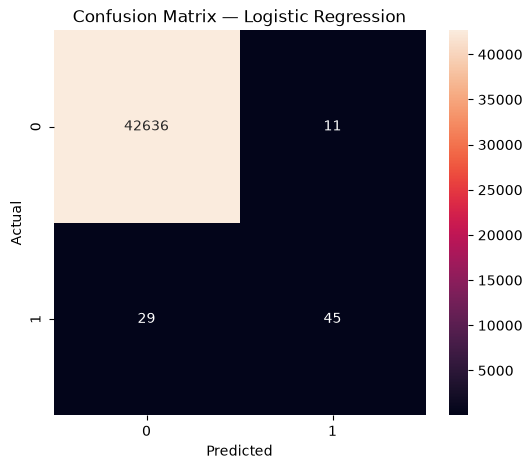

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_val_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9991


In [33]:
from sklearn.metrics import precision_score

In [34]:
precision = precision_score(y_val, y_val_pred)

print(f"Precision: {precision:.4f}")

Precision: 0.8036


In [35]:
from sklearn.metrics import recall_score

recall = recall_score(y_val, y_val_pred)

print(f"Recall: {recall:.4f}")

Recall: 0.6081


In [36]:
from sklearn.metrics import f1_score

f1 = f1_score(y_val, y_val_pred)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.6923


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42647
           1       0.80      0.61      0.69        74

    accuracy                           1.00     42721
   macro avg       0.90      0.80      0.85     42721
weighted avg       1.00      1.00      1.00     42721



In [38]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_val, y_val_proba)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9544


In [39]:
from sklearn.metrics import average_precision_score

In [40]:
pr_auc = average_precision_score(y_val, y_val_proba)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.6705


In [41]:
print("========== LOGISTIC REGRESSION BASELINE ==========")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

========== LOGISTIC REGRESSION BASELINE ==========
Accuracy : 0.9991
Precision: 0.8036
Recall   : 0.6081
F1 Score : 0.6923
ROC-AUC  : 0.9544
PR-AUC   : 0.6705


In [42]:
threshold = 0.30

y_val_pred_30 = (y_val_proba >= threshold).astype(int)

In [43]:
print(classification_report(y_val, y_val_pred_30))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42647
           1       0.73      0.66      0.70        74

    accuracy                           1.00     42721
   macro avg       0.87      0.83      0.85     42721
weighted avg       1.00      1.00      1.00     42721



In [44]:
threshold = 0.10

y_val_pred_10 = (y_val_proba >= threshold).astype(int)

print(classification_report(y_val, y_val_pred_10))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42647
           1       0.71      0.72      0.71        74

    accuracy                           1.00     42721
   macro avg       0.85      0.86      0.86     42721
weighted avg       1.00      1.00      1.00     42721



In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

results = []

for threshold in thresholds:
    predictions = (y_val_proba >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, predictions, zero_division=0),
        "recall": recall_score(y_val, predictions, zero_division=0),
        "f1": f1_score(y_val, predictions, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1
0,0.05,0.643678,0.756757,0.695652
1,0.10,0.706667,0.716216,0.711409
2,0.20,0.739130,0.689189,0.713287
3,0.30,0.731343,0.662162,0.695035
4,0.40,0.813559,0.648649,0.721805
5,0.50,0.803571,0.608108,0.692308
6,0.60,0.796296,0.581081,0.671875
7,0.70,0.796296,0.581081,0.671875
8,0.80,0.784314,0.540541,0.640000
9,0.90,0.765957,0.486486,0.595041


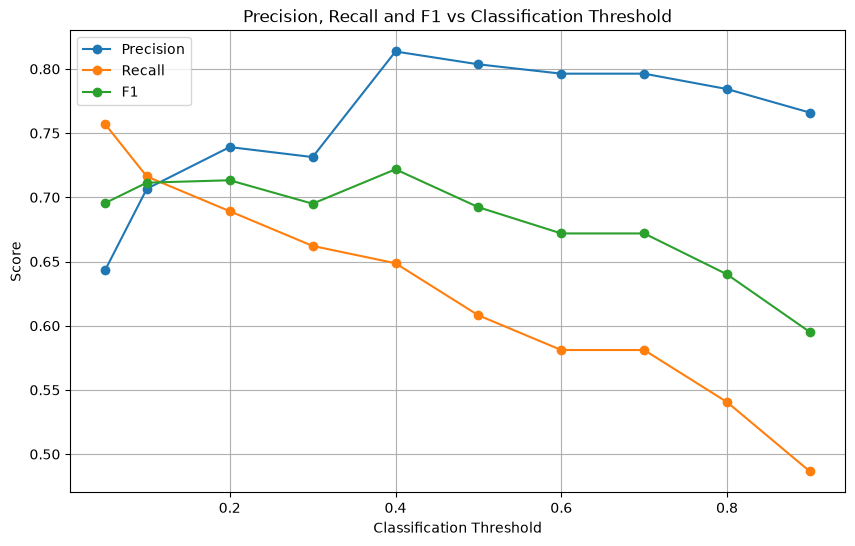

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Classification Threshold")

plt.legend()
plt.grid(True)

plt.show()